In [1]:
from models import *
from brian2 import *

import sys, os
import pickle as pk
import numpy as np
import pandas as pd
from itertools import product
import matplotlib.pyplot as plt
from rich import print as rprint
from multiprocessing import Pool

from utils import *

sys.path.append("../")
from sangrah.tools import get_info

sys.path.append('../../scripts_analysis')
from analysis import *

simTypes = {
    'control':     dict(d='control', r='result.dat', v='vesData.dat'),
    'without cross-talk': dict(d='control_eachCa', r='sresult_RRP_{}.dat', v='svesData_RRP_{}.dat'),
    'syt7KO':      dict(d='syt7KO', r='result.dat', v='vesData.dat'),
    'nonsatBuffer': dict(d='control_unsatBuffer', r='result.dat', v='vesData.dat')
}

dataPath = "../../data"

In [2]:
category_info_path = os.path.join(dataPath, 'control_eachCa/category_info.pk')
if os.path.exists(category_info_path):
    with open(category_info_path, "rb") as infile:
        category_info = pk.load(infile)

# rprint(category_info[0,0,0,0]['rep_design_median'])

categories = []
for category in category_info.ravel():
    # rprint(category)
    if category:
        categories.append(str(category['rep_design_median']))

# len(categories), categories

In [3]:
def run_sim(nMFB, spid, sptimes, tstep=0.1):
    defaultclock.dt = tstep*ms
    start_scope()

    MFBvrel = SpikeGeneratorGroup(nMFB, spid, sptimes*ms)

    nCA3p = nMFB
    CA3p = NeuronGroup(nCA3p, eqnCA3_PR, 
                    # method='exponential_euler', 
                    method='euler', 
                    threshold='Vs>0*mV', 
                    refractory='Vs>0*mV', 
                    namespace=CA3p_PR_params)
    CA3p.Vd = -61.3 * mV
    CA3p.Vs = -61.2 * mV

    # Synapse: MFB to CA3 pyramidal neuron
    MFB_CA3p_syn = Synapses(MFBvrel, CA3p,
                            model=eqs_MFB_CA3p_syn,
                            on_pre=MFB_CA3p_onpre,
                            # method='exponential_euler',
                            method='euler',
                            namespace=MFB_CA3p_syn_params)
    MFB_CA3p_syn.connect(j='i')

    # Monitors
    stMCA3p = StateMonitor(CA3p, ['Vd', 'Vs', 'Iampa', 'Inmda'], record=True)
    spMCA3p = SpikeMonitor(CA3p)

    # Run the simulation
    run(1210 * ms)

    return stMCA3p, spMCA3p

In [9]:
## Get MFB vesicle release times
tstep=0.01
design = categories[34]
simType = 'control'
print(design)

simInfo = get_info(design, skip=0)

if simType == 'without cross-talk':
    design = design.split('RRP')[0] + 'ISI' + design.split('ISI')[1]
resultDir = os.path.join(dataPath, simTypes[simType]['d'], design)
RRP = simInfo['RRP']
# print(design, RRP)

# ves_data_file = 'vesData.dat' if simType == 'control' else 'svesData.dat'

# print(simTypes[simType]['v'].format(RRP))
inf = os.path.join(resultDir, simTypes[simType]['v'].format(RRP))
with open(inf, "rb") as infile:
    vesData = pk.load(infile)
    # print(vesData.keys())
    
if simType == 'control':
    vrel_times = [[(1+float(val))*1000 for val in vals] for vals in vesData[RRP]]
    # vrel_times = vrel_times[:50] ##### For testing
else:
    seeds = len(vesData['AZ1']['sync'])
    vrel_times = [[] for _ in range(seeds)]
    for i in range(seeds):
        for az in list(vesData.keys()):
            for k in vesData[az].keys():
                vrel_times[i] += [(1+float(a))*1000 for a in vesData[az][k][i]] # Convert to ms
# print(vrel_times)

nMFB, spid, sptimes = get_spike_generator_info(vrel_times[:200])
# print(nMFB, np.array(spid), np.array(sptimes))


nVDCC_6_dVAZ_200_nAZ_29_RRP_50_ISI_20_nAP_10


In [14]:
MFB_CA3p_syn_params['g_AMPA'] = 0.1*mS
MFB_CA3p_syn_params['g_NMDA'] = 0.9*mS
MFB_CA3p_syn_params['tau_AMPA'] = 3*ms
CA3p_PR_params['Gc'] = 10*mS
CA3p_PR_params['p'] = 0.75
CA3p_PR_params['noise'] = 1*uA

In [15]:
# print(f"Running simulation for: {design}")
stMCA3p, spMCA3p = run_sim(nMFB, spid, sptimes, tstep=tstep)
# test_plot(stMCA3p, spMCA3p, vrel_times)

## Spike times of CA3p
CA3p_spikes = [np.sort([t-1000 for t in (a/ms).tolist() if t>1000]) for a in 
                spMCA3p.spike_trains().values()]

## Synaptic currents
epscs = -stMCA3p.Iampa[:,int(1000/tstep):]/uA

## timepoints
tt = stMCA3p.t[int(1000/tstep):]/ms - 1000

In [16]:
def test_plot(stMCA3p, spMCA3p, vrel_times):
    fig, axes = plt.subplots(2, 2, figsize=(10, 4), sharex=True)
    fig.subplots_adjust(wspace=0.2, hspace=0.1)
    # fig.suptitle("Simulation Results")

    ## Plot the CA3 spikes
    # axes[0,0].plot(stMCA3p.t/ms, stMCA3p.Vd[0]/mV, 'b-', label='Vd')
    axes[0,0].plot(stMCA3p.t/ms, stMCA3p.Vs[0]/mV, 'r-', label='Vs')
    axes[1,0].set_xlabel("Time (ms)")
    axes[0,0].set_ylabel("Membrane Potential (mV)")
    axes[0,0].legend(frameon=False)

    ## Plot the synaptic current
    axes[0,1].plot(stMCA3p.t/ms, -stMCA3p.Iampa[0]/uA, 'b-', label='I_ampa')
    axes[0,1].plot(stMCA3p.t/ms, -stMCA3p.Inmda[0]/uA, 'g-', label='I_nmda')
    axes[1,1].set_xlabel("Time (ms)")
    axes[0,1].set_ylabel(r"AMPA current ($\mu$A)")
    axes[0,1].legend(frameon=False)

    ## Raster plot of the CA3 spikes
    CA3p_sptimes = [a/ms for a in spMCA3p.spike_trains().values()]
    # axes[1,0].plot(spMCA3p.t/ms, spMCA3p.i, 'k.', markersize=2)
    axes[1,0].eventplot(CA3p_sptimes)

    ## Raster plot of the MFB vesicle releases
    axes[1,1].eventplot(vrel_times)

    for ax in axes.ravel():
        # ax.set_xlim(0, runt)
        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.tick_params(axis=u'both', which=u'both', length=2, labelsize=8)
        ax.set_xlim(900, 1210)
        ax.axvline(x=1000, color='black', linestyle='--', linewidth=0.5)

    plt.tight_layout()
    plt.show()

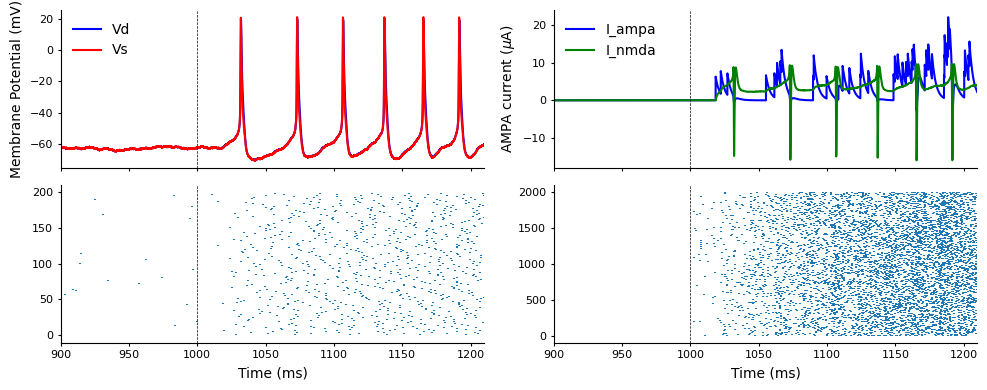

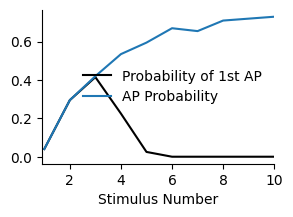

In [17]:
def _getAPprob(apTimes, tc=20, nAP=10):
    seeds = len(CA3p_spikes)
    # print(apTimes[:10])

    ## Stimulus times
    stimTimes = np.sort([1.5 + na*20 for na in range(nAP)])
    # print(stimTimes)
    
    ## AP probability
    apProb = np.zeros(nAP)
    for apts in apTimes:
        temp = np.zeros(nAP)
        for apt in apts:
            for i,st in enumerate(stimTimes):
                if np.ceil((st+tc-apt)/tc)==1:
                    temp[i] = 1
        apProb += temp
    apProb /= seeds

    ## probability of 1st AP
    ap1Prob = np.zeros(nAP)
    for apts in apTimes:
        # print(apts)
        temp = np.zeros(nAP)
        for i,st in enumerate(stimTimes):
            try:
                if np.ceil((st+tc-apts[0])/tc)==1:
                    temp[i] = 1
            except IndexError:
                continue
        ap1Prob += temp
    # print(ap1Prob)
    ap1Prob /= seeds
    
    return apProb, ap1Prob

test_plot(stMCA3p, spMCA3p, vrel_times)

ISI, nAP = 20, 10
apProb, ap1Prob = _getAPprob(CA3p_spikes)

fig, axs = plt.subplots(1, figsize=(3, 2))
fig.subplots_adjust(wspace=0.2, hspace=0.15)

## AP Probability
axs.plot(range(1, nAP+1), ap1Prob, color='black', label='Probability of 1st AP')
axs.plot(range(1,11), apProb, label='AP Probability')

axs.set_xlim(0.9,10)
axs.legend(frameon=False)
axs.spines["right"].set_visible(False)
axs.spines["top"].set_visible(False)
axs.set_xlabel("Stimulus Number", fontsize=10)
plt.show()